This notebook is written to perform Fisher inference based on principal components. The constraint will be compared with normal Fisher inference ("fishchips")

In [1]:
import sys
sys.path.insert(0, "/home/quantumer/dmde_class_perturb-CEDE/python/build/lib.linux-x86_64-3.10")
import subprocess
import classy
print("classy imported from: \n",classy.__file__)
# import necessary modules
# uncomment to get plots displayed in notebook
import numpy as np
from classy import Class
from scipy.optimize import fsolve
from scipy.interpolate import interp1d
from scipy.interpolate import interp2d
import os
import math
from scipy.interpolate import UnivariateSpline
import csv

classy imported from: 
 /home/quantumer/dmde_class_perturb-CEDE/python/build/lib.linux-x86_64-3.10/classy.cpython-310-x86_64-linux-gnu.so


In [2]:
# Cosmological parameters:
z_max_rec = 1e6
a_ini_over_a_today_default = 1e-14
z_max_pk = 1e10       # highest redshift involved
z_max_thermo = 5e7
start_tau_k = 0.00001
k_per_decade = 250     # number of k values, controls final resolution
k_min_tau0 = .001       # this value controls the minimum k value in the figure (it is k_min * tau0)
P_k_max_inv_Mpc =5   # this value is directly the maximum k value in the figure in Mpc
tau_num_early = 1000   # number of conformal time values before recombination, controls final resolution
tau_num_late = 500     # number of conformal time values after recombination, controls final resolution
                       # first value of conformal time in Mpc
h = 0.6732117

In [3]:
def get_sound_speeds(phi_scf_ini): #(0.6732117, 0.4, 0.5, 0.1)
    common_settings = {# which output? transfer functions only
                   'output':'mTk',
                   # LambdaCDM parameters
                   'h':0.6732117,
                   'omega_b': 0.02238280e0,
                   'omega_cdm':0.12038e0,
                   'g_scf': -0.013,
                   'm_scf': 14.3,
                   'frac_dmde': 0.8,
                   'phi_scf_ini': phi_scf_ini,
                   'N_ur': 2.0328,
                   'omega_ncdm': 0.0006451439,
                   'N_ncdm': 1,
                   'm_ncdm': 0.06,
                   'T_ncdm': 0.71611,
                   'tau_reio':0.05430842e0,
                   'Omega_k': 0.,
                   'A_s': 2.100549e-09,
                  'n_s': 0.9660499e0,
                   # Take fixed value for primordial Helium (instead of automatic BBN adjustment)
                   'YHe': 0.2454006e0,
                   # other output and precision parameters
                   'z_max_pk':z_max_pk,
                   # to get a larger z_max in recfast, 
                   # we must increase both recfast_z_initial 
                   # and the number of sampled values recfast_Nz0
                   # (in order to keep the same stepzize asd in the default: Delta z = 0.5)
                    'recfast_Nz0':z_max_rec*2.,
                    'recfast_z_initial':z_max_rec,
                   #'k_step_sub':'0.01',
                    'k_per_decade_for_pk':k_per_decade,
                    'k_per_decade_for_bao':k_per_decade,
                   'k_min_tau0':k_min_tau0, # this value controls the minimum k value in the figure
                #    'perturb_sampling_stepsize':'0.005',
                   'P_k_max_1/Mpc':P_k_max_inv_Mpc,
                   #'compute damping scale':'yes', # needed to output and plot Silk damping scale
                   'gauge':'synchronous'}

    ###############
    #
    # call CLASS
    #
    ###############
    # print("Starting CLASS\n")

    M_pre = Class()
    M_pre.set(common_settings)
    M_pre.compute()

    # print("CLASS is done!\n")

    background = M_pre.get_background() # load background table                                                                                                                           
    #print background.viewkeys()                                                                                                                                                          
    background_tau = background['conf. time [Mpc]'] # read conformal times in background table       
    background_z = background['z'] # read redshift
    background_tau_at_z = interp1d(background_z,background_tau)

    tau_ini = background_tau_at_z(z_max_pk)
    # print(tau_ini)
    times = M_pre.get_current_derived_parameters(['tau_rec','conformal_age'])
    tau_rec=times['tau_rec']
    tau_0 = times['conformal_age']
    tau1 = np.logspace(math.log10(tau_ini),math.log10(5*tau_rec),tau_num_early)
    tau2 = np.logspace(math.log10(5*tau_rec),math.log10(tau_0),tau_num_late)[1:]
    tau2[-1]=tau_0
    tau2[-1] *= 0.999999 # this tiny shift avoids interpolation errors
    tau= np.concatenate((tau1,tau2))
    tau_num = len(tau)

    background_z = background['z'] # read redshift
    background_aH = background['H [1/Mpc]']/(1.+background['z'])

    background_rho_cdm = background['(.)rho_cdm'] # read rho cdm in background table
    background_rho_nu = background['(.)rho_ur'] # read rho nu in background table

    background_z_at_tau = interp1d(background_tau,background_z, kind='cubic')
    a_tau = 1/(1+background_z_at_tau(tau))

    background_aH_at_a = interp1d(1/(background_z+1),background_aH, kind='cubic')
    background_aH_at_tau = interp1d(background_tau,background_aH, kind='cubic')
    background_a_at_tau = interp1d(background_tau,1/(background_z+1), kind='cubic')

    background_rho_cdm_tau = interp1d(background_tau,background_rho_cdm, kind='cubic')
    background_rho_nu_tau = interp1d(background_tau,background_rho_nu, kind='cubic')

    background_rho_phi = background['(.)rho_scf']
    background_p_phi = background['(.)p_scf']
    background_rho_phi_tau = interp1d(background_tau,background_rho_phi, kind='cubic')
    background_p_phi_tau = interp1d(background_tau,background_p_phi, kind='cubic')

    background_rho_ncdm = background['(.)rho_ncdm[0]']
    background_rho_ncdm_tau = interp1d(background_tau,background_rho_ncdm, kind='cubic')
    background_p_ncdm = background['(.)p_ncdm[0]']
    background_p_ncdm_tau = interp1d(background_tau,background_p_ncdm, kind='cubic')

    rho_total = background_rho_cdm + background_rho_nu + background_rho_phi + background_rho_ncdm
    rho_total_at_a_interp = UnivariateSpline(1/(1+background_z),rho_total, s = 0)
    rho_total_at_a_list = rho_total_at_a_interp(a_tau)
    # w_T_ncdm = background_p_ncdm/background_rho_ncdm
    # w_T_phi = background_p_phi/background_rho_phi
    w_T_general = (1/3*background_rho_nu+background_p_phi+background_p_ncdm)/(background_rho_cdm+background_rho_nu+background_rho_phi+background_rho_ncdm)
    # w_T_general = (1/3*background_rho_nu+background_p_phi)/(background_rho_cdm+background_rho_nu+background_rho_phi)

    w_T_at_a_interp = UnivariateSpline(1/(1+background_z),w_T_general,s=0)
    w_T_at_a_list = w_T_at_a_interp(a_tau)

    w_T_at_a_prime_interp = w_T_at_a_interp.derivative()
    w_T_at_a_prime_list = w_T_at_a_prime_interp(a_tau)

    w_ncdm_at_a_interp = UnivariateSpline(1/(1+background_z),background_p_ncdm/background_rho_ncdm,s=0)
    w_ncdm_at_a_list = w_ncdm_at_a_interp(a_tau)
    w_ncdm_at_a_prime_interp = w_ncdm_at_a_interp.derivative()
    w_ncdm_at_a_prime_list = w_ncdm_at_a_prime_interp(a_tau)
    p_ncdm_at_a_interp = UnivariateSpline(1/(1+background_z),background_p_ncdm,s=0)
    p_ncdm_at_a_list = p_ncdm_at_a_interp(a_tau)

    p_phi_at_a_interp = UnivariateSpline(1/(1+background_z),background_p_phi,s=0)
    p_phi_at_a_list = p_phi_at_a_interp(a_tau)
    rho_phi_at_a_interp = UnivariateSpline(1/(1+background_z),background_rho_phi,s=0)
    rho_phi_at_a_list = rho_phi_at_a_interp(a_tau)
    w_phi_at_a_interp = UnivariateSpline(1/(1+background_z),background_p_phi/background_rho_phi,s=0)
    w_phi_at_a_list = w_phi_at_a_interp(a_tau)


    ones = np.ones(len(background_z))   
    ca2_list = w_T_at_a_interp(1/(1+background_z)) - 1./3.*1/(1+background_z)*w_T_at_a_prime_interp(1/(1+background_z))/(ones+w_T_at_a_interp(1/(1+background_z)))
    ca2_a = interp1d(1/(1+background_z),ca2_list)

    ones = np.ones(len(a_tau))
    ca2_list = w_T_at_a_list - 1./3.*a_tau*w_T_at_a_prime_list/(1+w_T_at_a_list)
    ca2_tau = interp1d(tau,ca2_list)

    w_T_tau = interp1d(background_tau,w_T_general)

    # print(background_z_at_tau(tau[0]))
    # print("Computing the perturbations\n")
    one_time = M_pre.get_transfer(background_z_at_tau(tau[0]))
    k = one_time['k (h/Mpc)']
    k_num = len(k)

    cs2_d = np.zeros((tau_num,k_num))
    delta_d = np.zeros((tau_num,k_num))
    theta_d = np.zeros((tau_num,k_num))
    c2eff_d = np.zeros((tau_num,k_num))
    Dc2_d = np.zeros((tau_num,k_num))

    for i in range(tau_num):
        one_time = M_pre.get_transfer(background_z_at_tau(tau[i]))
        
        delta_d[i,:] = (one_time['d_ur'][:]*background_rho_nu_tau(tau[i]) + one_time['d_cdm'][:]*background_rho_cdm_tau(tau[i]) + one_time['d_scf'][:]*background_rho_phi_tau(tau[i]) + one_time['d_ncdm[0]'][:]*background_rho_ncdm_tau(tau[i]))\
        /(background_rho_cdm_tau(tau[i])+background_rho_nu_tau(tau[i])+background_rho_phi_tau(tau[i])+background_rho_ncdm_tau(tau[i]))
        
        cs2_d[i,:] = (1./3.*one_time['d_ur'][:]*background_rho_nu_tau(tau[i])+one_time['d_scf'][:]*background_p_phi_tau(tau[i])+one_time['d_ncdm[0]'][:]*background_p_ncdm_tau(tau[i]))\
                /(background_rho_cdm_tau(tau[i])*one_time['d_cdm'][:]+background_rho_nu_tau(tau[i])*one_time['d_ur'][:]+background_rho_phi_tau(tau[i])*one_time['d_scf'][:]+background_rho_ncdm_tau(tau[i])*one_time['d_ncdm[0]'][:])
        
        # delta_d[i,:] = (one_time['d_ur'][:]*background_rho_nu_tau(tau[i]) + one_time['d_cdm'][:]*background_rho_cdm_tau(tau[i]) + one_time['d_scf'][:]*background_rho_phi_tau(tau[i]))\
        # /(background_rho_cdm_tau(tau[i])+background_rho_nu_tau(tau[i])+background_rho_phi_tau(tau[i]))
        
        # cs2_d[i,:] = (1./3.*one_time['d_ur'][:]*background_rho_nu_tau(tau[i])+one_time['d_scf'][:]*background_p_phi_tau(tau[i]))\
        #         /(background_rho_cdm_tau(tau[i])*one_time['d_cdm'][:]+background_rho_nu_tau(tau[i])*one_time['d_ur'][:]+background_rho_phi_tau(tau[i])*one_time['d_scf'][:])
        
        # cs2_d[i,:] = (1./3.*one_time['d_ur'][:]*background_rho_nu_tau(tau[i]))\
        #          /(background_rho_cdm_tau(tau[i])*one_time['d_cdm'][:]+background_rho_nu_tau(tau[i])*one_time['d_ur'][:])
        
    
    common_settings = {# which output? transfer functions only
                   'output':'vTk',
                   # LambdaCDM parameters
                   'h':0.6732117,
                   'omega_b': 0.02238280e0,
                   'omega_cdm':0.12038e0,
                   'g_scf': -0.013,
                   'm_scf': 14.3,
                   'frac_dmde': 0.8,
                   'phi_scf_ini': phi_scf_ini,
                   'N_ur': 2.0328,
                   'omega_ncdm': 0.0006451439,
                   'N_ncdm': 1,
                   'm_ncdm': 0.06,
                   'T_ncdm': 0.71611,
                   'tau_reio':0.05430842e0,
                   'Omega_k': 0.,
                   'A_s': 2.100549e-09,
                  'n_s': 0.9660499e0,
                   # Take fixed value for primordial Helium (instead of automatic BBN adjustment)
                   'YHe': 0.2454006e0,
                   # other output and precision parameters
                   'z_max_pk':z_max_pk,
                   # to get a larger z_max in recfast, 
                   # we must increase both recfast_z_initial 
                   # and the number of sampled values recfast_Nz0
                   # (in order to keep the same stepzize asd in the default: Delta z = 0.5)
                    'recfast_Nz0':z_max_rec*2.,
                    'recfast_z_initial':z_max_rec,
                   #'k_step_sub':'0.01',
                    'k_per_decade_for_pk':k_per_decade,
                    'k_per_decade_for_bao':k_per_decade,
                   'k_min_tau0':k_min_tau0, # this value controls the minimum k value in the figure
                #    'perturb_sampling_stepsize':'0.005',
                   'P_k_max_1/Mpc':P_k_max_inv_Mpc,
                   #'compute damping scale':'yes', # needed to output and plot Silk damping scale
                   'gauge':'synchronous'}
    
    M_pre = Class()
    M_pre.set(common_settings)
    M_pre.compute()

    one_time = M_pre.get_transfer(background_z_at_tau(tau[0]))
    k = one_time['k (h/Mpc)']
    k_num = len(k)

    for i in range(tau_num):
        one_time = M_pre.get_transfer(background_z_at_tau(tau[i])) # transfer functions at each time tau

        theta_d[i,:] = ((1+1/3)*one_time['t_ur'][:]*background_rho_nu_tau(tau[i])+(1+w_phi_at_a_list[i])*one_time['t__scf'][:]*background_rho_phi_tau(tau[i])+(1+w_ncdm_at_a_list[i])*one_time['t_ncdm[0]']*background_rho_ncdm_tau(tau[i]))\
        /(background_rho_cdm_tau(tau[i])+(1+1/3)*background_rho_nu_tau(tau[i])+(1+w_phi_at_a_list[i])*background_rho_phi_tau(tau[i])+(1+w_ncdm_at_a_list[i])*background_rho_ncdm_tau(tau[i]))

        # theta_d[i,:] = ((1+1/3)*one_time['t_ur'][:]*background_rho_nu_tau(tau[i])+(1+w_phi_at_a_list(i))*one_time['t__scf'][:]*background_rho_phi_tau(tau[i]))\
        # /(background_rho_cdm_tau(tau[i])+(1+1/3)*background_rho_nu_tau(tau[i])+(1+w_phi_at_a_list(i))*background_rho_phi_tau(tau[i]))
        
        c2eff_d[i,:] = ((k*h)**2*cs2_d[i,:]*delta_d[i,:]+3*background_aH_at_tau(tau[i])*ca2_tau(tau[i])*(1+w_T_tau(tau[i]))*theta_d[i,:])\
        /((k*h)**2*delta_d[i,:]+3*background_aH_at_tau(tau[i])*(1+w_T_tau(tau[i]))*theta_d[i,:])
        Dc2_d[i,:] = c2eff_d[i,:]-ca2_tau(tau[i])
    
    return k, a_tau, rho_total_at_a_list, w_T_at_a_list, w_T_at_a_prime_list, c2eff_d

Read in PCs, eigenvalues and other infos.

In [4]:
# function to read in grid values
def grab_grid(gdmdir,NC,kmin,kmax,amin,amax,epsilon):
    kl=[]
    kr=[]
    al=[]
    ar=[]
    i=0
    with open('table_'+str(NC)+'_kmin_'+str(kmin)+'_kmax_'+str(kmax)+'_amin_'+str(amin)+'_amax_'+str(amax)+'_eps_'+str(epsilon)+'_2000_1000_fix_tscale_260.79.txt','rt',newline='') as f:
        data = csv.reader(f)
        for row in data:
            queue=row[:]
            al.append(float(row[2]))
            ar.append(float(row[3]))
            kl.append(float(row[0]))
            kr.append(float(row[1]))   
            i+=1
    ravelsize=i
    g=open(os.path.join(gdmdir,'w_T_2000_1000_fix.dat'))
    a=[]
    w=[] 
    dwda=[]
    for line in g:
        a.append(float(line.split()[0])) 
        w.append(float(line.split()[1])) 
        dwda.append(float(line.split()[2])) 
    NT=np.size(w)
    a_arr=np.array(a)
    h=open(os.path.join(gdmdir,'k_values_2000_1000_fix.dat') )
    kvals=[] 
    for line in h: 
        kvals.append(float(line.split()[0])) 
    NK=np.size(kvals) 
    return NT,NK,ravelsize,al,ar,kl,kr,kvals,a_arr


# function to read in joint PC
def joint_pc_cs2_grab(gdmdir,NC,NCw,ss,ssw,width,expt,l_no_lens,pol_no_pol,amin,amax,kmin,kmax,ravelsize,cap,cap_com):
    nc_str=str(NC)
    PC = np.zeros((cap_com,ravelsize+NCw))  # sound speed PC size + w PC size

    print('polar,',pol_no_pol)
    ns_str=str(ss)
    if (pol_no_pol=='wpol'):
        # This line needs to be modified to match the new filename convention if needed
        fname=gdmdir+'rw_pc_'+'cs2_w_coarse_amr_NC_'+nc_str+'_NCw_'+str(NCw)+'_s_'+ns_str+'_wstep_'+str(ssw)+'_a_'+str(width)+'_amin_'+str(amin)+'_amax_'+str(amax)+'_kmin_'+str(kmin)+'_kmax_'+str(kmax)+'_'+expt+'_cap_com_'+str(cap_com)
        print(fname)
    elif (pol_no_pol=='onlypol'):
        fname=gdmdir+'rw_pc_'+'onlypol_cs2_w_coarse_amr_NC_'+nc_str+'_NCw_'+str(NCw)+'_s_'+ns_str+'_wstep_'+str(ssw)+'_a_'+str(width)+'_amin_'+str(amin)+'_amax_'+str(amax)+'_kmin_'+str(kmin)+'_kmax_'+str(kmax)+'_'+expt+'_cap_'+str(cap)+'_cap_com_'+str(cap_com)
    if (l_no_lens=='lens'):
        fname+='_2000_1000_fix_ones_svary_l_just_joint.dat'
    else:
        # This line needs to be modified to match the new filename convention if needed
        fname+='_ones_svary_short.dat'
    i=0
    with open(fname,'r',newline='') as f:
        data=csv.reader(f)
        print('fnamen=',fname)
        for row in data:
            PC[:,i]=row[:]
            i+=1
        print(i)
    return PC

# function to read in joint eigenvalues
def joint_grab_eval(gdmdir,NC,NCw,cap,cap_com,expt,ss,ssw,width,amin,amax,kmin,kmax):
    nc_str=str(NC)
    fname=gdmdir+'rw_evals_cs2_w_coarse_amr_NC_'+nc_str+'_NCw_'+str(NCw)+'_s_'+str(ss)+'_wstep_'+str(ssw)+'_a_'+str(width)+'_amin_'+str(amin)+'_amax_'+str(amax)+'_kmin_'+str(kmin)+'_kmax_'+str(kmax)+'_'+expt+'_cap_com_'+str(cap_com)+'_2000_1000_fix_ones_svary_l_just_joint.dat'
    print(fname)
    with open(fname,'rt',newline='')as f:
        data=csv.reader(f)
        for row in data:
            evals=row
    evals=np.array(evals,dtype=float)

    return evals
    

In [5]:
# Basic parameters for grid and joint PC/eigenvalues
i=0
NC=74
kmin=0.04e0
kmax=0.4e0
amin=4.e-5
amax=0.009
epsilon=1
pol='pol'
lnl='none'
expt='planck'
ss=500.0
ssw = 0.008
cap=1000
exemcontrol=0
choose=1
pcmaxind=1000
cap_com=1000
NCw = 4338
width =0.0125
gdmdir = '/mnt/e/Dropbox/gdm_files/'
gdmdir1 = '/mnt/c/Users/jimmy/Downloads/'

In [6]:
NT,NK,ravelsize,al,ar,kl,kr,kvals,a_arr=grab_grid(gdmdir,NC,kmin,kmax,amin,amax,epsilon)
print(NT,NK,ravelsize,al,ar,kl,kvals,a_arr)

2999 4926 33130 [4e-05, 4.095067415255563e-05, 4.161690432706941e-05, 4.229430643096013e-05, 4.2983077675410454e-05, 4.3683413969943104e-05, 4.439552672645189e-05, 4.5119623903628684e-05, 4.5855913945233954e-05, 4.660462091545269e-05, 4.73659607600302e-05, 4.8140162162410605e-05, 4.892745569030264e-05, 4.972807286846533e-05, 5.054225801726819e-05, 5.137024898930596e-05, 5.2212300989141665e-05, 5.306866212288779e-05, 5.3939595197015466e-05, 5.48253629753509e-05, 5.572623213199724e-05, 5.664248328306604e-05, 5.757438793502448e-05, 5.852223783631479e-05, 5.9486325627888836e-05, 6.046694139289974e-05, 6.146439324298533e-05, 6.247899184094151e-05, 6.351105240705306e-05, 6.456089112632921e-05, 6.562884144526476e-05, 6.671523913387511e-05, 6.782042608802689e-05, 6.894475126259076e-05, 7.008857083985722e-05, 7.125224840265649e-05, 7.243615511236873e-05, 7.36406698919376e-05, 7.486617961409635e-05, 7.611307929496382e-05, 7.738177229313446e-05, 7.867267051457195e-05, 7.998619462334092e-05, 8.132

In [7]:
# Read in joint PC
PC=np.zeros((pcmaxind,ravelsize+NCw))
PC[:,:]=joint_pc_cs2_grab(gdmdir,NC,NCw,ss,ssw,width,expt,'lens','wpol',amin,amax,kmin,kmax,ravelsize,cap,cap_com)

polar, wpol
/mnt/e/Dropbox/gdm_files/rw_pc_cs2_w_coarse_amr_NC_74_NCw_4338_s_500.0_wstep_0.008_a_0.0125_amin_4e-05_amax_0.009_kmin_0.04_kmax_0.4_planck_cap_com_1000
fnamen= /mnt/e/Dropbox/gdm_files/rw_pc_cs2_w_coarse_amr_NC_74_NCw_4338_s_500.0_wstep_0.008_a_0.0125_amin_4e-05_amax_0.009_kmin_0.04_kmax_0.4_planck_cap_com_1000_2000_1000_fix_ones_svary_l_just_joint.dat


37468


In [8]:
# Read in joint eigenvalues
eval = joint_grab_eval(gdmdir,NC,NCw,cap,cap_com,expt,ss,ssw,width,amin,amax,kmin,kmax)

/mnt/e/Dropbox/gdm_files/rw_evals_cs2_w_coarse_amr_NC_74_NCw_4338_s_500.0_wstep_0.008_a_0.0125_amin_4e-05_amax_0.009_kmin_0.04_kmax_0.4_planck_cap_com_1000_2000_1000_fix_ones_svary_l_just_joint.dat


In [9]:
# Get original Fisher matrix
eval = np.array(eval)
eval = eval.astype(float)
Fisher_Matrix_Original = np.diag(eval)

In [10]:
# Read in Fiducial Model
w_T=open(os.path.join(gdmdir,'w_T_2000_1000_fix.dat'))
a_arb=[]
w_arb=[] 
dwda_arb=[]
for line in w_T:
    a_arb.append(float(line.split()[0])) 
    w_arb.append(float(line.split()[1])) 
    dwda_arb.append(float(line.split()[2])) 
a_arr_arb=np.array(a_arb)
w_arr_arb = np.array(w_arb)
k=open(os.path.join(gdmdir,'k_values_2000_1000_fix.dat'))
kvals_arb=[] 
for line in k:
    kvals_arb.append(float(line.split()[0])) 
kvals_arr_arb=np.array(kvals_arb)
NT=np.size(w_arb)
NK=np.size(kvals_arb) 

cs2_1d_arb=[] 
cs2_2d_arb=np.zeros((NT,NK))
jj=open(os.path.join(gdmdir,'cs2_T_2000_1000_fix.dat'))
cc=0
for line in jj:
    cs2_1d_arb.append(float(line.split()[0]))
    iplace=cc//NK
    jplace=cc%NK
    cs2_2d_arb[iplace,jplace]=cs2_1d_arb[cc]
    cc+=1
sound_speed_arb=cs2_2d_arb

In [11]:
# Get fiducial 
k, a_tau, rho_total_at_a_list, w_T_at_a_list, w_T_at_a_prime_list, c2eff_d = get_sound_speeds(1e-5)

In [12]:
# The function to interpolate the grid for models. This is useful since the grid is not uniform in k and a.
from scipy.interpolate import griddata

def interpolate_grid(cs2, a, k, a_new, k_new):
    
    # Create a meshgrid for the original data
    K, A = np.meshgrid(k, a)
    
    # Flatten the meshgrid and cs2 for griddata
    points = np.array([K.flatten(), A.flatten()]).T
    values = cs2.flatten()
    
    # Create a meshgrid for the new axis
    K_new, A_new = np.meshgrid(k_new, a_new)
    
    # Perform the interpolation
    cs2_new = griddata(points, values, (K_new, A_new), method='linear')
    
    return cs2_new

In [13]:
# An example to set the new axis for interpolation
# The setting logic is to add 3 points between each two points in the axis for both a and k within ar and al, kr and kl
# Assuming ar, al, kr, kl are arrays
a_new_log = []
k_new_log = []

# Converting to log scale
ar_log = np.log(ar)
al_log = np.log(al)
kr_log = np.log(kr)
kl_log = np.log(kl)


# Interpolation logic in log scale
for i in range(ravelsize):
    a_new_log.append((ar_log[i] + al_log[i]) / 2)
    k_new_log.append((kr_log[i] + kl_log[i]) / 2)


# Remove duplicates and convert back to the original scale
a_new_log = np.array(list(dict.fromkeys(a_new_log)))
k_new_log = np.array(list(dict.fromkeys(k_new_log)))

# Convert back from log scale to original scale
a_new = np.sort(np.exp(a_new_log))
k_new = np.sort(np.exp(k_new_log))

print(len(a_new), len(k_new))

1259 73


In [14]:
from tqdm import tqdm

def choose_pixel_mod(npix, kl_pixels, kr_pixels, al_pixels, ar_pixels, k, a, cs2):
    
    kl = np.array(kl_pixels)
    kr = np.array(kr_pixels)
    al = np.array(al_pixels)
    ar = np.array(ar_pixels)
    kd, ad = np.meshgrid(k, a)
    cs_2 = []
    
    for i in tqdm(range(npix), desc="Processing Pixels"):
        s = np.logical_and(ad >= al[i], ad <= ar[i])
        t = np.logical_and(kd >= kl[i], kd <= kr[i])
        u = np.logical_and(s, t)
        cs_2.append(np.sum(cs2[np.where(u == 1)])/np.count_nonzero(u))
    
    cs_2_arr = np.array(cs_2)
    
    return cs_2_arr

In [15]:
cs2_fid_new = interpolate_grid(cs2_2d_arb, a_arr, kvals, a_new, k_new)
cs2_fid_arr = choose_pixel_mod(ravelsize, kl, kr, al, ar, k_new, a_new, cs2_fid_new)

Processing Pixels: 100%|██████████| 33130/33130 [00:08<00:00, 4131.87it/s]


In [16]:
# Get gaussian basis functions for w and energy density
def get_darr_Barr(NCw, width, a_arr_cede, NT_cede):
    a0_pca = 4e-5
    a0max = 0.009

    lacen_arr=np.linspace(np.log(a0_pca),np.log(a0max),NCw)
    npix_n=np.size(lacen_arr)
    acen_arr=np.exp(lacen_arr)

    darr = np.zeros((npix_n,NT_cede))

    B=np.zeros((npix_n,NT_cede))
  
    rho_a=np.zeros((npix_n,NT_cede))
    Barr_a=np.zeros((npix_n,NT_cede))

    darr_a=darr
    lacen_arr_a=lacen_arr
    acen_arr_a=np.exp(lacen_arr_a)

    for i in range(1,npix_n+1):
        amp=ss
        delta=amp*np.exp(-0.5*((np.log(a_arr_cede[range(NT_cede)]) -np.log(acen_arr[i-1]))**2 )/width**2)
        B[i-1] = np.log(a_arr_cede[range(NT_cede)]/acen_arr[i-1])*delta/(3.0*width*width*(1.+delta))
        darr[i-1]=delta
        darr_a[i-1]=delta
        Barr_a=B

    return darr_a, Barr_a

In [17]:
# Find differences in w and cs2 from fiducial
def cs2_w_diff(phi, rho_lcdm):
    k, a_cede, rho_cede, w_cede, w_T_prime, cs2 = get_sound_speeds(*phi)

    a_arr_cede=np.array(a_cede)
    cs2_cede_new = interpolate_grid(cs2, a_arr_cede, k, a_new, k_new)
    cs2_cede_arr = choose_pixel_mod(ravelsize, kl, kr, al, ar, k_new, a_new, cs2_cede_new)
    cs2_cede_diff = cs2_cede_arr - cs2_fid_arr
    
    # To set the same starting and ending for w for both models
    delta_rho_over_rho = (rho_cede - rho_lcdm)/rho_lcdm
    
    # Cut off the unused parts for w
    a0_pca=4.e-5
    a0max=0.009
    idx = []
    NT_cede=np.size(delta_rho_over_rho)
    for i in range(NT_cede):
        if (a_arr_cede[i]<=a0_pca):
            idx.append(i)
        if (a_arr_cede[i]>=a0max):
            idx.append(i)

    delta_rho_over_rho = np.delete(delta_rho_over_rho, idx)
    a_arr_cede = np.delete(a_arr_cede, idx)
    NT_cede=np.size(delta_rho_over_rho)

    # Generate basis functions
    darr_a, Barr_a = get_darr_Barr(NCw, width, a_arr_cede, NT_cede)

    return delta_rho_over_rho, cs2_cede_diff, darr_a, Barr_a

### Contribution for Joint Principal Components

The contribution for joint PCs is defined as

$$
q = \langle \delta w, B \rangle,
$$

where $B$ is the corresponding **Gaussian basis function**.

The **Jacobian matrix** \(J\) is

$$
J_{ij} = \frac{\left\langle \mathrm{PC}, \, [\,\delta c_s^{2}, \; q] \right\rangle}{\epsilon_{j}}.
$$


### Fisher Inference Based on Principal Components

$$
F_\mathrm{new} = J^T \,F \, J
$$

### Constraints from $F_\mathrm{new}$

$$
\sigma = \sqrt{F_\mathrm{new}^{-1}}
$$


In [18]:
# Compute numerical Jacobian
def compute_jacobian_numerical(phi, rho_lcdm, PC, epsilon):
    n_dot_prod = np.size(PC, 0)
    n_phi = len(phi)
    
    J = np.zeros((n_dot_prod, n_phi))
    
    delta_rho_over_rho0, cs2_cede_diff0, darr_a, Barr_a = cs2_w_diff(phi, rho_lcdm)
    
    for i in range(n_phi):
        phi_perturbed = np.copy(phi)
        phi_perturbed[i] += epsilon[i]
        
        delta_rho_over_rho, cs2_cede_diff, darr_a, Barr_a = cs2_w_diff(phi_perturbed, rho_lcdm)
        qqqq=np.matmul(np.linalg.pinv(darr_a).T, delta_rho_over_rho)

        total_target = np.concatenate((cs2_cede_diff - cs2_cede_diff0, qqqq))
        dot_prod_perturbed = np.matmul(PC, total_target)

        J[:, i] = dot_prod_perturbed / epsilon[i]
    
    return J


In [19]:
def compute_jacobian_numerical(phi, a_arr, w_fid, PC, epsilon):
    n_dot_prod = np.size(PC, 0)
    n_phi = len(phi)
    
    J = np.zeros((n_dot_prod, n_phi))
    w_cede_diff0, cs2_cede_diff0, darr_a, Barr_a = cs2_w_diff(phi, w_fid, a_arr)
    
    
    for i in range(n_phi):
        phi_perturbed_plus = np.copy(phi)
        phi_perturbed_minus = np.copy(phi)
        phi_perturbed_plus[i] += epsilon[i]
        phi_perturbed_minus[i] -= epsilon[i]
        
        w_cede_diff_plus, cs2_cede_diff_plus, darr_a_plus, Barr_a_plus = cs2_w_diff(phi_perturbed_plus, w_fid, a_arr)
        w_cede_diff_minus, cs2_cede_diff_minus, darr_a_minus, Barr_a_minus = cs2_w_diff(phi_perturbed_minus, w_fid, a_arr)
        
        qqqq=np.matmul(np.linalg.pinv(Barr_a).T,w_cede_diff_plus - w_cede_diff_minus)

        
        total_target = np.concatenate((cs2_cede_diff_plus - cs2_cede_diff_minus, qqqq))
        
        dot_prod_perturbed = np.matmul(PC, total_target)
        J[:, i] = dot_prod_perturbed / (2 * epsilon[i])
    
    return J

In [19]:
def transform_fisher_matrix(F_orig, J):
    """
    Transform the original Fisher information matrix to new parameters.
    
    Parameters:
        F_orig (numpy array): Original Fisher information matrix (n x n).
        J (numpy array): Jacobian matrix (n x m).
    
    Returns:
        F_new (numpy array): Transformed Fisher information matrix (m x m).
    """
    # Compute the transformed Fisher information matrix
    F_new = J.T @ F_orig @ J  # Resulting shape (m, m)
    return F_new

In [20]:
def invert_fisher_matrix(F):
    """
    Invert the Fisher information matrix.
    
    Parameters:
        F (numpy array): Fisher information matrix (n x n).
    
    Returns:
        F_inv (numpy array): Inverted Fisher information matrix (n x n).
    """
    # Invert the Fisher information matrix
    F_inv = np.linalg.pinv(F)
    return F_inv

In [21]:
def error(F_inv):
    """
    Compute the error from the inverted Fisher information matrix.
    
    Parameters:
        F_inv (numpy array): Inverted Fisher information matrix (n x n).
    
    Returns:
        error (numpy array): Error (n x n).
    """
    # Compute the error
    error = np.sqrt(np.diag(F_inv))
    return error

In [22]:
phi = np.array([1e-5,])
epsilon = np.array([0.01,])
J = compute_jacobian_numerical(phi, rho_total_at_a_list, PC, epsilon)

Processing Pixels: 100%|██████████| 33130/33130 [00:08<00:00, 4131.73it/s]


In [43]:
J

array([[ 8.48263416e-07],
       [ 3.04596028e-06],
       [-2.66827887e-05],
       [-2.26256786e-05],
       [-2.01979683e-05],
       [-4.71054864e-05],
       [-1.67277993e-06],
       [-6.51850326e-05],
       [ 2.13438940e-05],
       [ 1.59136879e-05],
       [-2.02054783e-05],
       [ 2.57466564e-05],
       [ 2.74914141e-05],
       [-2.84112557e-05],
       [-1.51712460e-05],
       [ 1.97691976e-05],
       [ 1.46032526e-05],
       [-9.24006045e-06],
       [ 5.39704293e-05],
       [ 2.58757498e-05],
       [ 2.31778337e-05],
       [-2.28605431e-05],
       [ 3.45136088e-06],
       [-1.36896414e-05],
       [-1.94383521e-05],
       [ 9.29944486e-06],
       [-2.85763440e-05],
       [-4.79138837e-05],
       [ 1.82279157e-05],
       [-4.16940982e-05],
       [ 2.04393947e-05],
       [-2.61105630e-05],
       [ 3.67298325e-05],
       [-1.83509313e-05],
       [ 1.64654746e-05],
       [ 4.12294357e-06],
       [-6.80205500e-05],
       [-8.21823258e-05],
       [ 9.7

In [24]:
F_new = transform_fisher_matrix(Fisher_Matrix_Original, J)
F_new_inv = invert_fisher_matrix(F_new)

In [45]:
F_new

array([[0.00215082]])

In [23]:
from fishchips.cosmo import Observables
from fishchips.experiments import CMB_Primary
import fishchips.util
pars = ['phi_scf_ini',]
centers = np.array([1e-5])
steps = np.array([0.01])
obs = Observables(parameters=pars,
                  fiducial=centers,
                  left = centers,
                  right=centers+steps)

In [25]:
classy_template = {'output': 'tCl pCl lCl',
                   'l_max_scalars': 3500,
                    'h':0.6732117,
                   'omega_b': 0.02238280e0,
                   'omega_cdm':0.12038e0,
                   'frac_dmde': 0.8,
                   'g_scf': -0.013,
                   'm_scf': 14.3,
                   'N_ur': 2.0328,
                   'omega_ncdm': 0.0006451439,
                   'N_ncdm': 1,
                   'm_ncdm': 0.06,
                   'T_ncdm': 0.71611,
                   'tau_reio':0.05430842e0,
                   'Omega_k': 0.,
                   'A_s': 2.100549e-09,
                  'n_s': 0.9660499e0,
                   'YHe': 0.2454006e0,
                    'lensing':'yes',
                    # 'P_k_max_1/Mpc': 1.0,
                   'gauge':'synchronous'}
# add in the fiducial values too
classy_template.update(dict(zip(obs.parameters, obs.fiducial)))

In [26]:
# generate the fiducial cosmology
obs.compute_cosmo(key='fiducial', classy_dict=classy_template)

# generate an observables dictionary, looping over parameters
for par, par_left, par_right in zip(obs.parameters, obs.left, obs.right):
    classy_left = classy_template.copy()
    classy_left[par] = par_left
    classy_right = classy_template.copy()
    classy_right[par] = par_right
    # pass the dictionaries full of configurations to get computed
    obs.compute_cosmo(key=par + '_left', classy_dict=classy_left)
    obs.compute_cosmo(key=par + '_right', classy_dict=classy_right)

In [27]:
# compute the Fisher matrix with a Planck-like experiment
example_Planck = fishchips.experiments.CMB_Primary(
    theta_fwhm=[7.], sigma_T=[33.], sigma_P=[56.],
    f_sky=0.65, l_min=2, l_max=2500
)
fisher = example_Planck.get_fisher(obs)
cov = np.linalg.inv(fisher)

['$\\phi_{scf}$']
['$\\phi_{scf}$']


(<Figure size 600x600 with 1 Axes>,
 array([[<Axes: xlabel='$\\phi_{scf}$'>]], dtype=object))

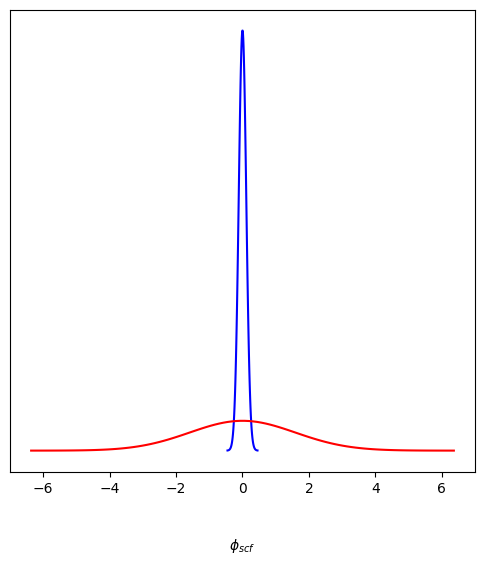

In [28]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 1, squeeze=False, figsize=(6,6))

fishchips.util.plot_triangle(
    obs,
    cov,
    fig,
    ax,
    color='blue',
    labels=[r'$\phi_{scf}$']
)

fishchips.util.plot_triangle(
    obs,
    F_new_inv,
    fig,
    ax,
    color='red',
    labels=[r'$\phi_{scf}$']
)

In [62]:
import numpy as np
import matplotlib.pyplot as plt

def plot_1d_gaussians_from_cov(
    bestfit,
    cov_list,
    legend_labels=None,
    colors=None,
    nsig_show=(1, 2),
    x_nsig=5.0,
    ngrid=800,
    fill=True,
    title=None,
    xlabel="parameter",
    ylabel="pdf",
):
    """
    Plot 1D Gaussian(s) given mean bestfit and covariance(s) (variance).

    cov_list can be:
      - a scalar variance (e.g. 0.04)
      - a (1,1) array (e.g. np.array([[0.04]]))
      - a list/tuple mixing the above (e.g. [0.04, np.array([[0.01]])])
    """
    mu = float(np.asarray(bestfit).ravel()[0])

    # ---- robust normalization: ensure we have a Python list of cov objects
    if isinstance(cov_list, (list, tuple)):
        cov_items = list(cov_list)
    else:
        cov_items = [cov_list]

    # ---- extract variances safely
    variances = []
    for C in cov_items:
        C = np.asarray(C, dtype=float)

        if C.ndim == 0:
            var = float(C)
        elif C.shape == (1, 1):
            var = float(C[0, 0])
        else:
            raise ValueError(f"Each covariance must be a scalar or shape (1,1). Got shape {C.shape}.")

        if var < 0:
            raise ValueError(f"Variance must be >= 0; got {var}.")
        variances.append(var)

    sigmas = np.sqrt(np.array(variances))
    K = len(sigmas)

    if legend_labels is None:
        legend_labels = [f"set {i+1}" for i in range(K)]
    if colors is None:
        colors = [None] * K

    if len(legend_labels) != K:
        raise ValueError("legend_labels must match number of covariances.")
    if len(colors) != K:
        raise ValueError("colors must match number of covariances.")

    sigma_max = float(sigmas.max()) if K else 1.0
    if sigma_max == 0:
        sigma_max = 1.0

    x = np.linspace(mu - x_nsig * sigma_max, mu + x_nsig * sigma_max, ngrid)

    fig, ax = plt.subplots(figsize=(7, 4.2))

    for s, label, col in zip(sigmas, legend_labels, colors):
        if s == 0:
            ax.axvline(mu, lw=2.2, color=col, label=f"{label} (sigma=0)")
            continue

        pdf = np.exp(-0.5 * ((x - mu) / s) ** 2) / (s * np.sqrt(2 * np.pi))
        ax.plot(x, pdf, lw=2.0, color=col, label=label)
        ax.axvline(mu, lw=1.0, color=col, alpha=0.6)

        if fill and nsig_show:
            for ns in sorted(nsig_show, reverse=True):
                lo, hi = mu - ns * s, mu + ns * s
                mask = (x >= lo) & (x <= hi)
                ax.fill_between(
                    x[mask], 0, pdf[mask],
                    color=col,
                    alpha=0.08 if ns > 1 else 0.15
                )
                
    ax.set_xlim(-2,2)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)
    ax.legend(frameon=True)
    ax.tick_params(direction="in", top=True, right=True)
    plt.tight_layout()
    return fig, ax


In [53]:
PC_number = [1, 2, 3, 4, 5, 10, 20, 30, 40, 50, 100]
phi = np.array([1e-5,])
epsilon = np.array([0.2,])

def PC_number_vs_cov(PC_number, PC, F_orig):
    cov = []
    for n in PC_number:
        PC_truncated = PC[:n, :]
        J_truncated = compute_jacobian_numerical(phi, a_arr_arb, w_arr_arb, PC_truncated, epsilon)
        F_orig_truncated = F_orig[:n, :n]
        F_new_truncated = transform_fisher_matrix(F_orig_truncated, J_truncated)
        F_new_truncated_inv = invert_fisher_matrix(F_new_truncated)
        cov.append(F_new_truncated_inv)  # Assuming we're interested in the first parameter's variance
    return cov

cov_list = PC_number_vs_cov(PC_number, PC, Fisher_Matrix_Original)
# for i, cov_PCA in enumerate(cov_list):
#     fig, ax = plot_1d_gaussians_from_cov(
#         bestfit=obs.fiducial,
#         cov_list=[cov, cov_PCA],
#         legend_labels=[f"Fisher", f"PCs: {PC_number[i]}"],
#         colors=["C1", "C2"],
#         xlabel=r"$g_{\rm scf}$",
#         title=f"Covariance with {PC_number[i]} PCs"
#     )
        

Processing Pixels: 100%|██████████| 33130/33130 [00:07<00:00, 4421.93it/s]


In [23]:
PC_number = [1, 2, 3, 4, 5, 10, 20]

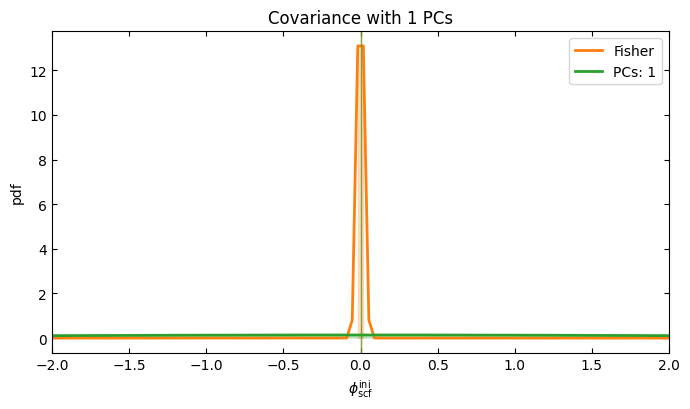

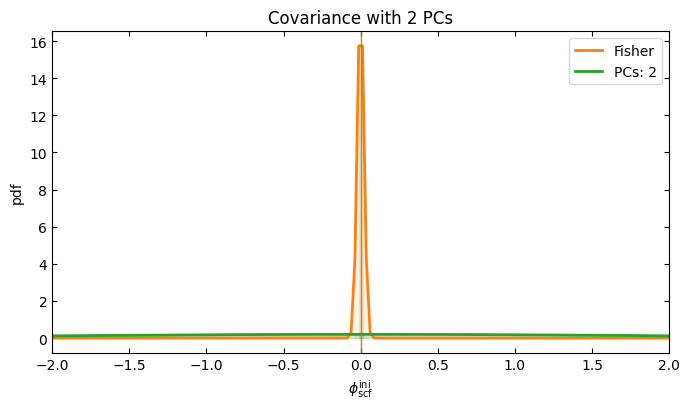

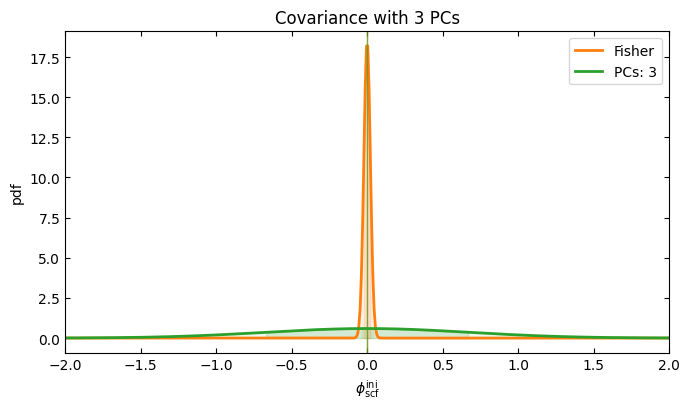

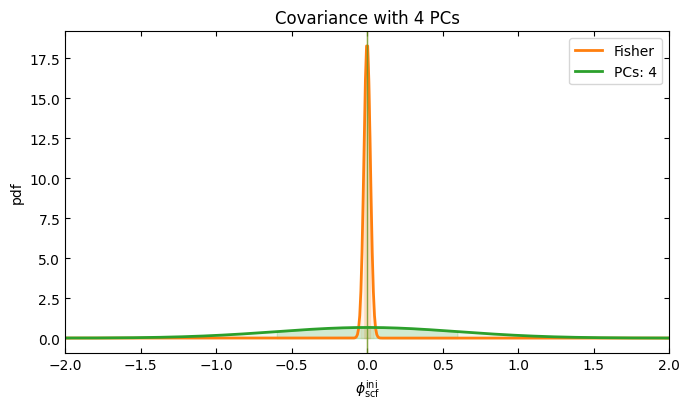

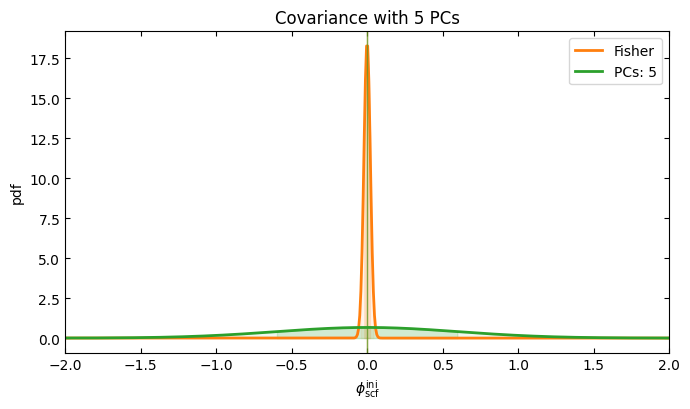

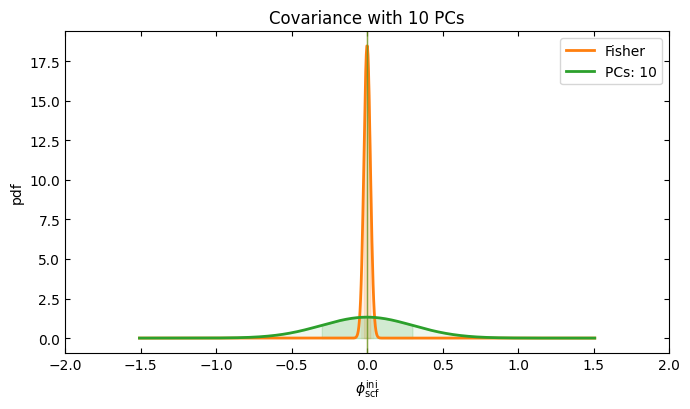

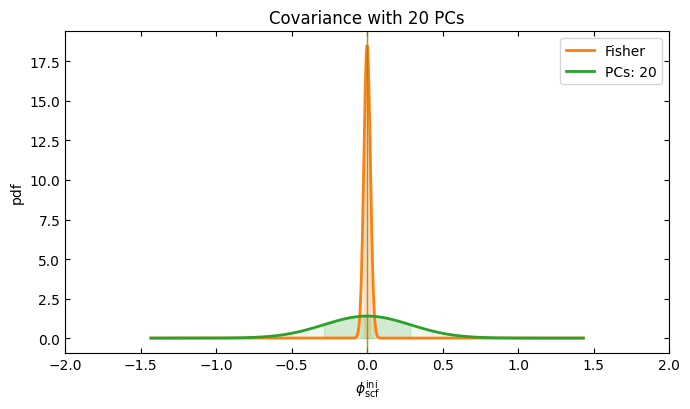

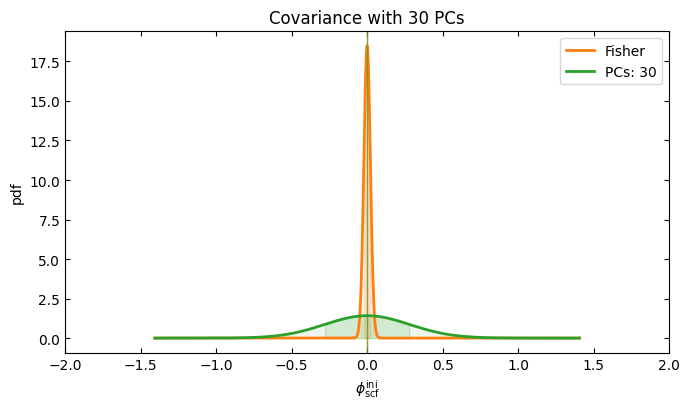

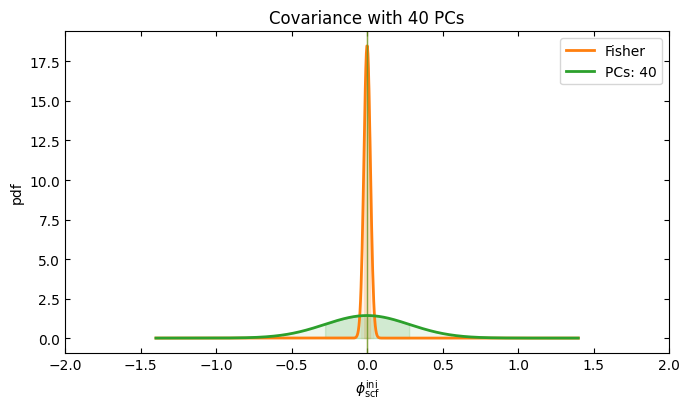

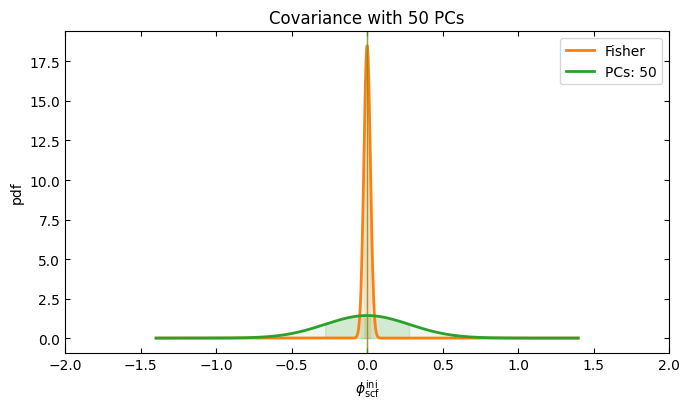

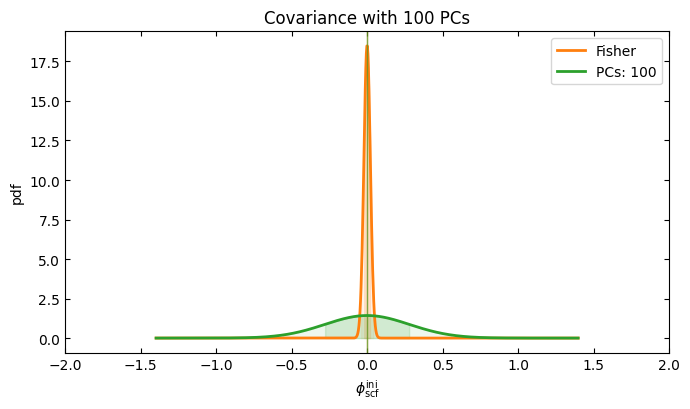

In [63]:
for i, cov_PCA in enumerate(cov_list):
    fig, ax = plot_1d_gaussians_from_cov(
        bestfit=obs.fiducial,
        cov_list=[cov, cov_PCA],
        legend_labels=[f"Fisher", f"PCs: {PC_number[i]}"],
        colors=["C1", "C2"],
        xlabel=r"$\phi_{\rm scf}^{\rm ini}$",
        title=f"Covariance with {PC_number[i]} PCs"
    )

In [47]:
cov

array([[0.0078546]])

In [45]:
Fisher_Matrix_Original.shape

(1000, 1000)

In [72]:
for i, value in enumerate(np.sqrt(cov_list)):
    print('For', PC_number[i], 'PCs, the error is:', value)

For 1 PCs, the error is: [[2.8700308]]
For 2 PCs, the error is: [[1.96938532]]
For 3 PCs, the error is: [[0.67114907]]
For 4 PCs, the error is: [[0.60111764]]
For 5 PCs, the error is: [[0.60039972]]
For 10 PCs, the error is: [[0.3015621]]
For 20 PCs, the error is: [[0.28639213]]
For 30 PCs, the error is: [[0.28129079]]
For 40 PCs, the error is: [[0.27974067]]
For 50 PCs, the error is: [[0.27955823]]
For 100 PCs, the error is: [[0.2795432]]


In [43]:
F_new_inv

array([[0.0781444]])

In [81]:
def get_sound_speeds(m_scf): #(0.6732117, 0.4, 0.5, 0.1)
    common_settings = {# which output? transfer functions only
                   'output':'mTk',
                   # LambdaCDM parameters
                   'h':0.6732117,
                   'omega_b': 0.02238280e0,
                   'omega_cdm':0.12038e0,
                   'frac_dmde': 1,
                   'g_scf': -0.013,
                   'm_scf': m_scf,
                   'phi_scf_ini': 0.001,
                   'N_ur': 2.0328,
                   'omega_ncdm': 0.0006451439,
                   'N_ncdm': 1,
                   'm_ncdm': 0.06,
                   'T_ncdm': 0.71611,
                   'tau_reio':0.05430842e0,
                   'Omega_k': 0.,
                   'A_s': 2.100549e-09,
                  'n_s': 0.9660499e0,
                   # Take fixed value for primordial Helium (instead of automatic BBN adjustment)
                   'YHe': 0.2454006e0,
                   # other output and precision parameters
                   'z_max_pk':z_max_pk,
                   # to get a larger z_max in recfast, 
                   # we must increase both recfast_z_initial 
                   # and the number of sampled values recfast_Nz0
                   # (in order to keep the same stepzize asd in the default: Delta z = 0.5)
                    'recfast_Nz0':z_max_rec*2.,
                    'recfast_z_initial':z_max_rec,
                   #'k_step_sub':'0.01',
                    'k_per_decade_for_pk':k_per_decade,
                    'k_per_decade_for_bao':k_per_decade,
                   'k_min_tau0':k_min_tau0, # this value controls the minimum k value in the figure
                #    'perturb_sampling_stepsize':'0.005',
                   'P_k_max_1/Mpc':P_k_max_inv_Mpc,
                   #'compute damping scale':'yes', # needed to output and plot Silk damping scale
                   'gauge':'synchronous'}

    ###############
    #
    # call CLASS
    #
    ###############
    # print("Starting CLASS\n")

    M_pre = Class()
    M_pre.set(common_settings)
    M_pre.compute()

    # print("CLASS is done!\n")

    background = M_pre.get_background() # load background table                                                                                                                           
    #print background.viewkeys()                                                                                                                                                          
    background_tau = background['conf. time [Mpc]'] # read conformal times in background table       
    background_z = background['z'] # read redshift
    background_tau_at_z = interp1d(background_z,background_tau)

    tau_ini = background_tau_at_z(z_max_pk)
    # print(tau_ini)
    times = M_pre.get_current_derived_parameters(['tau_rec','conformal_age'])
    tau_rec=times['tau_rec']
    tau_0 = times['conformal_age']
    tau1 = np.logspace(math.log10(tau_ini),math.log10(5*tau_rec),tau_num_early)
    tau2 = np.logspace(math.log10(5*tau_rec),math.log10(tau_0),tau_num_late)[1:]
    tau2[-1]=tau_0
    tau2[-1] *= 0.999999 # this tiny shift avoids interpolation errors
    tau= np.concatenate((tau1,tau2))
    tau_num = len(tau)

    background_z = background['z'] # read redshift
    background_aH = background['H [1/Mpc]']/(1.+background['z'])

    background_rho_cdm = background['(.)rho_cdm'] # read rho cdm in background table
    background_rho_nu = background['(.)rho_ur'] # read rho nu in background table

    background_z_at_tau = interp1d(background_tau,background_z)
    a_tau = 1/(1+background_z_at_tau(tau))

    background_aH_at_a = interp1d(1/(background_z+1),background_aH)
    background_aH_at_tau = interp1d(background_tau,background_aH)
    background_a_at_tau = interp1d(background_tau,1/(background_z+1))

    background_rho_cdm_tau = interp1d(background_tau,background_rho_cdm)
    background_rho_nu_tau = interp1d(background_tau,background_rho_nu)

    background_rho_phi = background['(.)rho_scf']
    background_p_phi = background['(.)p_scf']
    background_rho_phi_tau = interp1d(background_tau,background_rho_phi)
    background_p_phi_tau = interp1d(background_tau,background_p_phi)

    background_rho_ncdm = background['(.)rho_ncdm[0]']
    background_rho_ncdm_tau = interp1d(background_tau,background_rho_ncdm)
    background_p_ncdm = background['(.)p_ncdm[0]']
    background_p_ncdm_tau = interp1d(background_tau,background_p_ncdm)

    # w_T_ncdm = background_p_ncdm/background_rho_ncdm
    # w_T_phi = background_p_phi/background_rho_phi
    w_T_general = (1/3*background_rho_nu+background_p_phi+background_p_ncdm)/(background_rho_cdm+background_rho_nu+background_rho_phi+background_rho_ncdm)
    # w_T_general = (1/3*background_rho_nu+background_p_phi)/(background_rho_cdm+background_rho_nu+background_rho_phi)

    w_T_at_a_interp = interp1d(1/(1+background_z),w_T_general)
    w_T_at_a_list = w_T_at_a_interp(a_tau)

    w_T_at_a_prime_interp = UnivariateSpline(1/(1+background_z),w_T_general,s=0).derivative()
    w_T_at_a_prime_list = w_T_at_a_prime_interp(a_tau)

    w_ncdm_at_a_interp = UnivariateSpline(1/(1+background_z),background_p_ncdm/background_rho_ncdm,s=0)
    w_ncdm_at_a_list = w_ncdm_at_a_interp(a_tau)
    w_ncdm_at_a_prime_interp = w_ncdm_at_a_interp.derivative()
    w_ncdm_at_a_prime_list = w_ncdm_at_a_prime_interp(a_tau)
    p_ncdm_at_a_interp = UnivariateSpline(1/(1+background_z),background_p_ncdm,s=0)
    p_ncdm_at_a_list = p_ncdm_at_a_interp(a_tau)

    p_phi_at_a_interp = UnivariateSpline(1/(1+background_z),background_p_phi,s=0)
    p_phi_at_a_list = p_phi_at_a_interp(a_tau)
    rho_phi_at_a_interp = UnivariateSpline(1/(1+background_z),background_rho_phi,s=0)
    rho_phi_at_a_list = rho_phi_at_a_interp(a_tau)
    w_phi_at_a_interp = UnivariateSpline(1/(1+background_z),background_p_phi/background_rho_phi,s=0)
    w_phi_at_a_list = w_phi_at_a_interp(a_tau)


    ones = np.ones(len(background_z))   
    ca2_list = w_T_at_a_interp(1/(1+background_z)) - 1./3.*1/(1+background_z)*w_T_at_a_prime_interp(1/(1+background_z))/(ones+w_T_at_a_interp(1/(1+background_z)))
    ca2_a = interp1d(1/(1+background_z),ca2_list)

    ones = np.ones(len(a_tau))
    ca2_list = w_T_at_a_list - 1./3.*a_tau*w_T_at_a_prime_list/(1+w_T_at_a_list)
    ca2_tau = interp1d(tau,ca2_list)

    w_T_tau = interp1d(background_tau,w_T_general)

    # print(background_z_at_tau(tau[0]))
    # print("Computing the perturbations\n")
    one_time = M_pre.get_transfer(background_z_at_tau(tau[0]))
    k = one_time['k (h/Mpc)']
    k_num = len(k)

    cs2_d = np.zeros((tau_num,k_num))
    delta_d = np.zeros((tau_num,k_num))
    theta_d = np.zeros((tau_num,k_num))
    c2eff_d = np.zeros((tau_num,k_num))
    Dc2_d = np.zeros((tau_num,k_num))

    for i in range(tau_num):
        one_time = M_pre.get_transfer(background_z_at_tau(tau[i]))
        
        delta_d[i,:] = (one_time['d_ur'][:]*background_rho_nu_tau(tau[i]) + one_time['d_cdm'][:]*background_rho_cdm_tau(tau[i]) + one_time['d_scf'][:]*background_rho_phi_tau(tau[i]) + one_time['d_ncdm[0]'][:]*background_rho_ncdm_tau(tau[i]))\
        /(background_rho_cdm_tau(tau[i])+background_rho_nu_tau(tau[i])+background_rho_phi_tau(tau[i])+background_rho_ncdm_tau(tau[i]))
        
        cs2_d[i,:] = (1./3.*one_time['d_ur'][:]*background_rho_nu_tau(tau[i])+one_time['d_scf'][:]*background_p_phi_tau(tau[i])+one_time['d_ncdm[0]'][:]*background_p_ncdm_tau(tau[i]))\
                /(background_rho_cdm_tau(tau[i])*one_time['d_cdm'][:]+background_rho_nu_tau(tau[i])*one_time['d_ur'][:]+background_rho_phi_tau(tau[i])*one_time['d_scf'][:]+background_rho_ncdm_tau(tau[i])*one_time['d_ncdm[0]'][:])
        
        # delta_d[i,:] = (one_time['d_ur'][:]*background_rho_nu_tau(tau[i]) + one_time['d_cdm'][:]*background_rho_cdm_tau(tau[i]) + one_time['d_scf'][:]*background_rho_phi_tau(tau[i]))\
        # /(background_rho_cdm_tau(tau[i])+background_rho_nu_tau(tau[i])+background_rho_phi_tau(tau[i]))
        
        # cs2_d[i,:] = (1./3.*one_time['d_ur'][:]*background_rho_nu_tau(tau[i])+one_time['d_scf'][:]*background_p_phi_tau(tau[i]))\
        #         /(background_rho_cdm_tau(tau[i])*one_time['d_cdm'][:]+background_rho_nu_tau(tau[i])*one_time['d_ur'][:]+background_rho_phi_tau(tau[i])*one_time['d_scf'][:])
        
        # cs2_d[i,:] = (1./3.*one_time['d_ur'][:]*background_rho_nu_tau(tau[i]))\
        #          /(background_rho_cdm_tau(tau[i])*one_time['d_cdm'][:]+background_rho_nu_tau(tau[i])*one_time['d_ur'][:])
        
    
    common_settings = {# which output? transfer functions only
                   'output':'vTk',
                   # LambdaCDM parameters
                   'h':0.6732117,
                   'omega_b': 0.02238280e0,
                   'omega_cdm':0.12038e0,
                   'frac_dmde': 1,
                   'g_scf': -0.013,
                   'm_scf': m_scf,
                   'phi_scf_ini': 0.001,
                   'N_ur': 2.0328,
                   'omega_ncdm': 0.0006451439,
                   'N_ncdm': 1,
                   'm_ncdm': 0.06,
                   'T_ncdm': 0.71611,
                   'tau_reio':0.05430842e0,
                   'Omega_k': 0.,
                   'A_s': 2.100549e-09,
                  'n_s': 0.9660499e0,
                   # Take fixed value for primordial Helium (instead of automatic BBN adjustment)
                   'YHe': 0.2454006e0,
                   # other output and precision parameters
                   'z_max_pk':z_max_pk,
                   # to get a larger z_max in recfast, 
                   # we must increase both recfast_z_initial 
                   # and the number of sampled values recfast_Nz0
                   # (in order to keep the same stepzize asd in the default: Delta z = 0.5)
                    'recfast_Nz0':z_max_rec*2.,
                    'recfast_z_initial':z_max_rec,
                   #'k_step_sub':'0.01',
                    'k_per_decade_for_pk':k_per_decade,
                    'k_per_decade_for_bao':k_per_decade,
                   'k_min_tau0':k_min_tau0, # this value controls the minimum k value in the figure
                #    'perturb_sampling_stepsize':'0.005',
                   'P_k_max_1/Mpc':P_k_max_inv_Mpc,
                   #'compute damping scale':'yes', # needed to output and plot Silk damping scale
                   'gauge':'synchronous'}
    
    M_pre = Class()
    M_pre.set(common_settings)
    M_pre.compute()

    one_time = M_pre.get_transfer(background_z_at_tau(tau[0]))
    k = one_time['k (h/Mpc)']
    k_num = len(k)

    for i in range(tau_num):
        one_time = M_pre.get_transfer(background_z_at_tau(tau[i])) # transfer functions at each time tau

        theta_d[i,:] = ((1+1/3)*one_time['t_ur'][:]*background_rho_nu_tau(tau[i])+(1+w_phi_at_a_list[i])*one_time['t__scf'][:]*background_rho_phi_tau(tau[i])+(1+w_ncdm_at_a_list[i])*one_time['t_ncdm[0]']*background_rho_ncdm_tau(tau[i]))\
        /(background_rho_cdm_tau(tau[i])+(1+1/3)*background_rho_nu_tau(tau[i])+(1+w_phi_at_a_list[i])*background_rho_phi_tau(tau[i])+(1+w_ncdm_at_a_list[i])*background_rho_ncdm_tau(tau[i]))

        # theta_d[i,:] = ((1+1/3)*one_time['t_ur'][:]*background_rho_nu_tau(tau[i])+(1+w_phi_at_a_list(i))*one_time['t__scf'][:]*background_rho_phi_tau(tau[i]))\
        # /(background_rho_cdm_tau(tau[i])+(1+1/3)*background_rho_nu_tau(tau[i])+(1+w_phi_at_a_list(i))*background_rho_phi_tau(tau[i]))
        
        c2eff_d[i,:] = ((k*h)**2*cs2_d[i,:]*delta_d[i,:]+3*background_aH_at_tau(tau[i])*ca2_tau(tau[i])*(1+w_T_tau(tau[i]))*theta_d[i,:])\
        /((k*h)**2*delta_d[i,:]+3*background_aH_at_tau(tau[i])*(1+w_T_tau(tau[i]))*theta_d[i,:])
        Dc2_d[i,:] = c2eff_d[i,:]-ca2_tau(tau[i])
    
    return k, a_tau, w_T_at_a_list, w_T_at_a_prime_list, c2eff_d

In [38]:
k_cede_0, a_cede_0, w_cede_0, w_T_prime_cede_0, cs2_cede_0 = get_sound_speeds(0.02,)
# k_cede_1, a_cede_1, w_cede_1, w_T_prime_cede_1, cs2_cede_1 = get_sound_speeds(0.1)

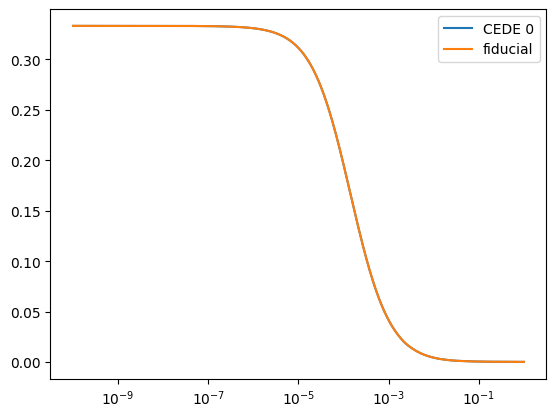

In [39]:
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

model = interp1d(a_cede_0, w_cede_0, kind='quadratic', fill_value="extrapolate")
w_cede_0_interp = model(a_arr_arb)

plt.plot(a_cede_0, w_cede_0, label='CEDE 0')
# plt.plot(a_cede_1, w_cede_1, label='CEDE 1')
plt.plot(a_arb, w_arb, label='fiducial')
plt.xscale('log')
plt.legend()

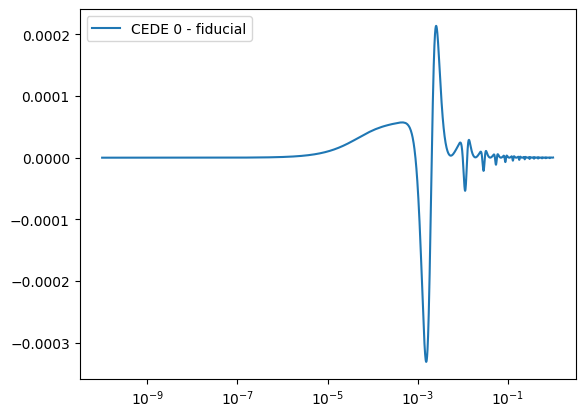

In [84]:
plt.plot(a_arr_arb, w_cede_0_interp - w_arb, label='CEDE 0 - fiducial')
plt.xscale('log')
plt.legend()

In [ ]:
phi = np.array([0.1,])
k_cede, a_cede, w_cede, w_T_prime_cede, cs2_cede = get_sound_speeds(*phi)

In [40]:
cs2_cede_new = interpolate_grid(cs2_cede, a_cede, k_cede, a_new, k_new)

In [41]:
cs2_cede_arr = choose_pixel_mod(ravelsize, kl, kr, al, ar, k_new, a_new, cs2_cede_new)

Processing Pixels: 100%|██████████| 33130/33130 [00:08<00:00, 3855.36it/s]


In [42]:
w_cede_diff, cs2_cede_diff, darr, Barr = cs2_w_diff(phi, w_arr_arb, a_arr_arb)

Processing Pixels: 100%|██████████| 33130/33130 [00:07<00:00, 4363.25it/s]


In [43]:
qqqq=np.matmul(np.linalg.pinv(Barr).T,w_cede_diff)
total_target = np.concatenate((cs2_cede_diff, qqqq))
dot_prod_perturbed = np.matmul(PC, total_target)

In [44]:
# Define the risk function
def risk(total_target, pcmaxind):
    sigma_2 = np.zeros(PC.shape[1])
    for i in range(PC.shape[1]):
        sigma_2[i] = np.sum(PC[0:pcmaxind,i]**2/eval[0:pcmaxind])
    dot_product = []
    for i in range(pcmaxind):
        dot_product.append(np.dot(PC[i,:], total_target))
    dot_product = np.array(dot_product)
    pc_all = np.zeros((PC.shape[1]))
    for i in range(pcmaxind):
        pc_all = PC[i,:]*dot_product[i] + pc_all
    b = pc_all - total_target
    return np.sum(sigma_2**2 + b**2)

  0%|          | 0/67 [00:00<?, ?it/s]

100%|██████████| 67/67 [00:06<00:00, 10.87it/s]


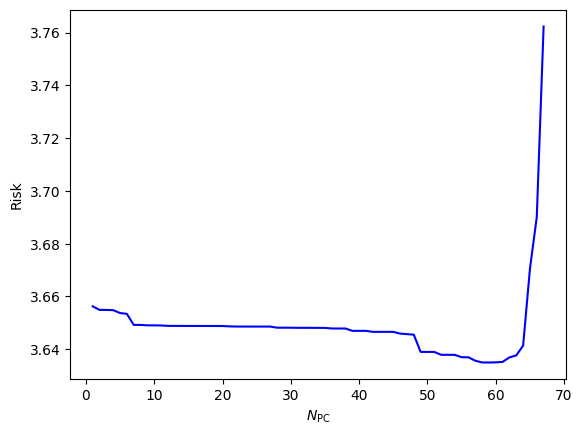

In [47]:
pcmaxind = np.arange(1, 68)
risk_cede = []
for i in tqdm(pcmaxind):
    risk_cede.append(risk(total_target, i))
risk_cede = np.array(risk_cede)
plt.plot(pcmaxind, risk_cede, color='blue')
plt.xlabel(r'$N_{\rm PC}$')
plt.ylabel(r'Risk')
# plt.legend()
plt.show()

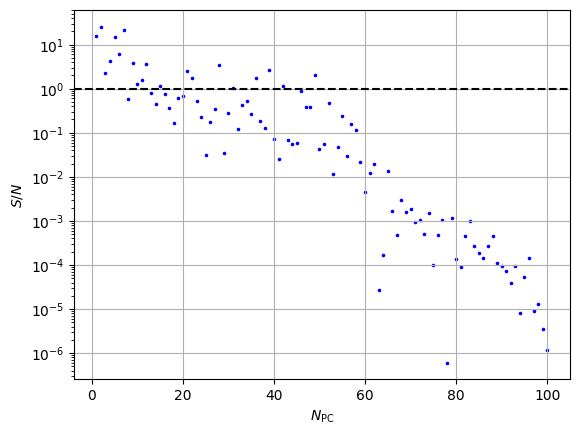

In [46]:
plt.scatter(np.arange(1, 101), abs(dot_prod_perturbed[0:100]*np.sqrt(eval[0:100])),marker = '.',color='blue',label=r'CEDE model',s=10)
plt.axhline(y=1, color='black', linestyle='--')
plt.yscale('log')
# plt.rcParams['font.size'] = 10
plt.xlabel(r'$N_{\rm PC}$')
plt.ylabel(r'$S/N$')
# plt.legend()
plt.grid()
plt.show()